In [ ]:
# -----------------------------
# The attemp of this module is to make sense of the data, AND easier to read/visual/explain to stake holder
#
# Histogram + Density Plot
# Check if your PREDICTION have a reasonable distribution compared to TRAINING data
#
# -----------------------------

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

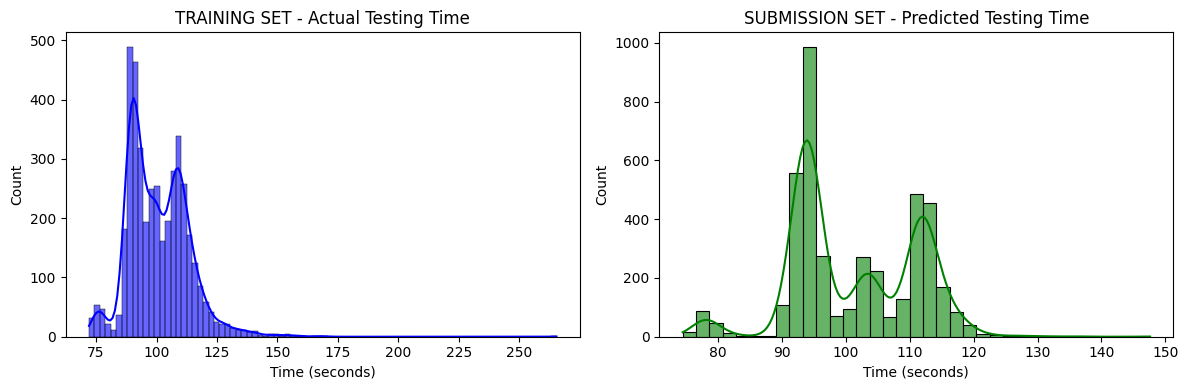

In [ ]:
# Load data

submission = pd.read_csv('submission.csv')
train = pd.read_csv('train.csv')

# 
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Training distribution
sns.histplot(train['y'], kde=True, ax=axes[0], color='blue', alpha=0.6)
axes[0].set_title('TRAINING SET - Actual Testing Time')
axes[0].set_xlabel('Time (seconds)')


# Prediction distribution
sns.histplot(submission['y'], kde=True, ax=axes[1], color='green', alpha=0.6)
axes[1].set_title('SUBMISSION SET - Predicted Testing Time')
axes[1].set_xlabel('Time (seconds)')

plt.tight_layout()
plt.savefig('prediction_distribution.png', dpi=300)
plt.show()

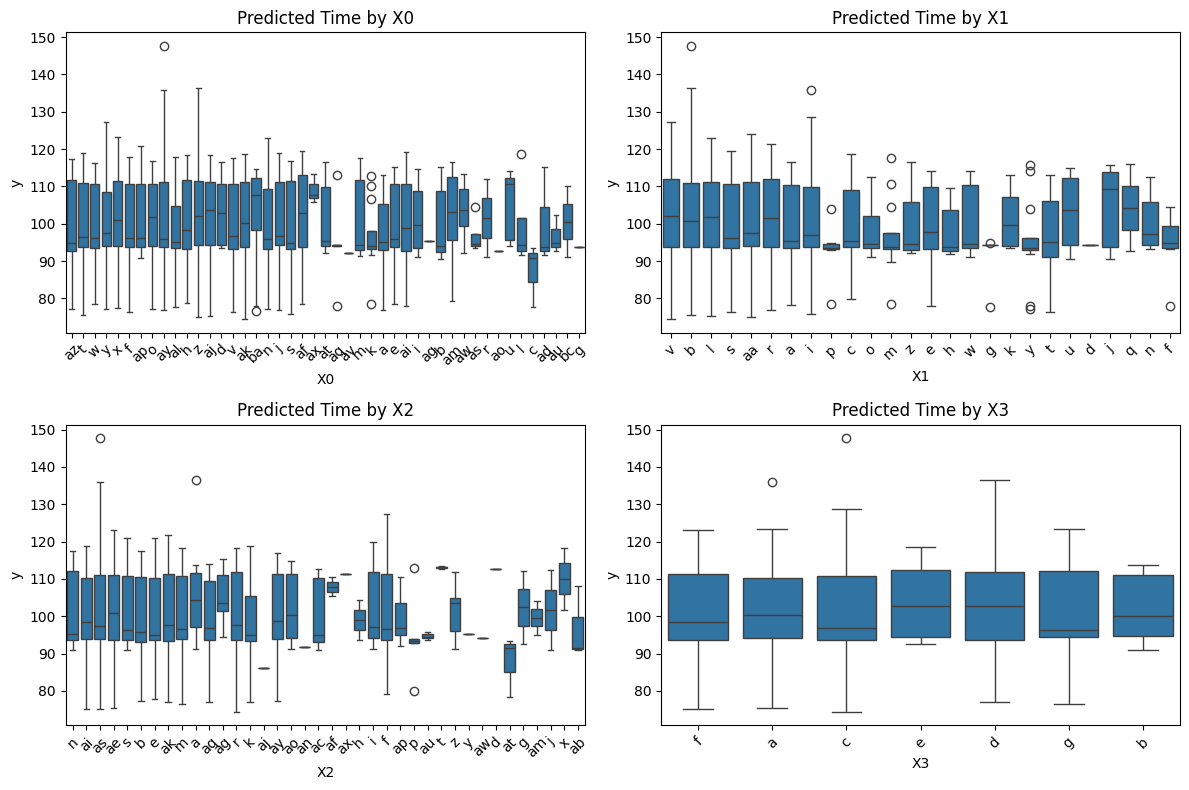

In [ ]:
# -----------------------------
#
# Merge predictions with test features
# 
# Box Plot by Categorical Features
#
# See if predictions make sense across different car configurations
# 
# -----------------------------

test = pd.read_csv('test.csv')
test_with_pred = test.merge(submission, on='ID')

# Pick top 4 categorical variables
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for idx, col in enumerate(['X0', 'X1', 'X2', 'X3']):
    row = idx // 2
    col_pos = idx % 2
    sns.boxplot(data=test_with_pred, x=col, y='y', ax=axes[row, col_pos])
    axes[row, col_pos].set_title(f'Predicted Time by {col}')
    axes[row, col_pos].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('predictions_by_category.png', dpi=300)
plt.show()

In [ ]:
print("=== PREDICTION DATA STATISTICS ===")
print(f"Count:     {len(submission['y'])}")
print(f"Mean:      {submission['y'].mean():.2f} seconds")
print(f"Median:    {submission['y'].median():.2f} seconds")
print(f"Std Dev:   {submission['y'].std():.2f}")
print(f"Min:       {submission['y'].min():.2f} seconds")
print(f"Max:       {submission['y'].max():.2f} seconds")
print(f"\n=== TRAINING COMPARISON ===")
print(f"Train Mean: {train['y'].mean():.2f} seconds")
print(f"Train Median: {train['y'].median():.2f} seconds")

=== PREDICTION DATA STATISTICS ===
Count:     4209
Mean:      101.08 seconds
Median:    97.67 seconds
Std Dev:   9.83
Min:       74.46 seconds
Max:       147.61 seconds

=== TRAINING COMPARISON ===
Train Mean: 100.67 seconds
Train Median: 99.15 seconds


In [ ]:
# Top 10 longest predicted times
top_10_high = submission.nlargest(10, 'y')
print("TOP 10 LONGEST PREDICTED TIMES:")
print(top_10_high)

# Top 10 shortest predicted times
top_10_low = submission.nsmallest(10, 'y')
print("\nTOP 10 SHORTEST PREDICTED TIMES:")
print(top_10_low)

print(f"Base on Top 10 Longest predicted time, the outlier seem to be high, while 1st Standard Deviation is 9.83")
print(f"Base on Top 10 Shortest time, the data is more pack and higher in precision, also because it is closer to the Min Value of 74.46 seconds, the data is reliable.")

TOP 10 LONGEST PREDICTED TIMES:
        ID           y
311    311  147.605100
3499  3499  136.373920
3460  3460  135.911700
4128  4128  132.267600
1390  1390  130.908070
3899  3899  128.826230
782    782  128.650860
1269  1269  128.046260
3536  3536  127.348710
1088  1088  126.647675

TOP 10 SHORTEST PREDICTED TIMES:
        ID          y
3824  3824  74.455480
3492  3492  74.537960
3006  3006  75.075520
4034  4034  75.255005
3147  3147  75.510460
2895  2895  75.639260
3593  3593  75.697235
4123  4123  75.699700
3270  3270  75.917340
1405  1405  76.229150
Base on Top 10 Longest predicted time, the outlier seem to be high, while 1st Standard Deviation is 9.83
Base on Top 10 Shortest time, the data is more pack and higher in precision, also because it is closer to the Min Value of 74.46 seconds, the data is reliable.
